In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
from scipy.stats import randint, uniform

## IMPORT & EXPLORE

In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

In [3]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to('cpu')
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [4]:
from sentence_transformers import SentenceTransformer

In [5]:
from torchvision import transforms
from PIL import Image
import torch

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

In [64]:
all_products_combined = pd.read_csv(r"C:\Users\User\Desktop\flip_vlm\flip_data_vlm\all_products_combined_ext.csv") 

In [65]:
all_products_combined = all_products_combined.drop(columns = ['Unnamed: 0'])

In [68]:
from pathlib import Path

def convert_to_windows_path(local_path):
    if "flip/data/" in local_path:
        relative = local_path.split("flip/data/")[-1]
        return str(Path(
            "C:/Users/User/Desktop/flip_vlm/flip_data_vlm"
        ) / relative)
    elif "flo_images/" in local_path:
        relative = local_path.split("flo_images/")[-1]
        return str(Path(
            "C:/Users/User/Desktop/flip_vlm/flip_data_vlm/flo_images"
        ) / relative)
    else:
        return ""

all_products_combined['windows_image_path'] = (
    all_products_combined['local_image_path']
    .fillna("")
    .astype(str)
    .apply(convert_to_windows_path)
)


In [9]:
all_products_combined.sample(10)

,title,local_image_path,product_url,windows_image_path
8905,Корзина-холодильник для пикника,/root/flip/data/category_1/images/Корзина_холо...,https://www.flip.kz/catalog?prod=2782298,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...
17417,Пакет подарочный «Любимые игрушки»,/root/flip/data/category_2/images/Пакет_подаро...,https://www.flip.kz/catalog?prod=2570769,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...
5879,Колесо рулевое съемное CS V2P RS057,/root/flip/data/category_4/images/Колесо_рулев...,https://www.flip.kz/catalog?prod=3206242,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...
26073,Мужской Белый,/flo_images/5c71b355ecbf_b1c6a170.jpg,https://www.flo.com.kz/ru/product/kinetix-int1...,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\f...
11346,Мяч баскетбольный «Тигр»,/root/flip/data/category_1/images/Мяч_баскетбо...,https://www.flip.kz/catalog?prod=4665199,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...
16868,Копилка «Astronaut»,/root/flip/data/category_2/images/Копилка_Astr...,https://www.flip.kz/catalog?prod=4220148,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...
27327,Мужской Шорты Серый,/flo_images/3efc0b3f88f1_17b36b72.jpg,https://www.flo.com.kz/ru/product/lumberjack-m...,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\f...
19979,"Электронные напольные весы SF-1911, черный",/root/flip/data/category_3/images/Электронные_...,https://www.flip.kz/catalog?prod=4851118,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...
25377,Мужской Кроссовки Бежевый,/flo_images/a274c8b5032a_24ff72d9.jpg,https://www.flo.com.kz/ru/product/lumberjack-s...,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\f...
1067,"Мультирум колонка Home Small, белый",/root/flip/data/category_4/images/Мультирум_ко...,https://www.flip.kz/catalog?prod=3437472,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...


In [10]:
all_products_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28448 entries, 0 to 28447
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   title               28448 non-null  object
 1   local_image_path    28447 non-null  object
 2   product_url         28448 non-null  object
 3   windows_image_path  28448 non-null  object
dtypes: object(4)
memory usage: 889.1+ KB


## CLEAN & PREPARE

In [11]:
device = 'cuda'

In [12]:
class FlipDualEncoderv2(nn.Module):
    def __init__(self, embedding_dim=256, device=device):
        super().__init__()
        self.device = device

        # ResNet50 as visual encoder
        resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        resnet50.fc = nn.Identity()
        self.visual_encoder = resnet50.to(device)
        self.image_projection = nn.Linear(2048, embedding_dim).to(device)

        # LaBSE as text encoder
        self.text_encoder = SentenceTransformer('sentence-transformers/LaBSE').to(device)
        self.text_projection = nn.Linear(768, embedding_dim).to(device)

    def forward(self, images=None, texts=None):
        image_embedding = None
        text_embedding = None

        if images is not None:
            print(f"📸 Got image tensor with shape: {images.shape}")
            try:
                image_encoded = self.visual_encoder(images)
                print("✅ ResNet output:", image_encoded.shape)
                image_embedding = F.normalize(self.image_projection(image_encoded), p=2, dim=-1)
                print("✅ Image embedding:", image_embedding.shape)
            except Exception as e:
                print(f"❌ Image encoding failed: {e}")

        if texts is not None:
            try:
                with torch.no_grad():
                    text_features = self.text_encoder.encode(
                        texts,
                        convert_to_tensor=True,
                        normalize_embeddings=False
                    )  # This returns on CPU by default
                text_features = text_features.to(self.device)  # ⬅️ ensure on correct device
                text_embedding = self.text_projection(text_features)
                text_embedding = F.normalize(text_embedding, p=2, dim=-1)
            except Exception as e:
                print(f"❌ Text encoding failed: {e}")

        print("🔁 Final image_embedding:", type(image_embedding), image_embedding.shape if image_embedding is not None else None)
        print("🔁 Final text_embedding:", type(text_embedding), text_embedding.shape if text_embedding is not None else None)
        
        return image_embedding, text_embedding


In [13]:
torch.cuda.get_device_properties()

_CudaDeviceProperties(name='NVIDIA GeForce RTX 3050 Laptop GPU', major=8, minor=6, total_memory=4095MB, multi_processor_count=16, uuid=15678e8c-abb7-821b-a8bf-1798d0455d2e, L2_cache_size=1MB)

In [14]:
flip_dual_encoderv2 = FlipDualEncoderv2().to(device)

In [15]:
flip_dual_encoderv2.load_state_dict( torch.load(r"C:\Users\User\Desktop\flip_vlm\models\flip_dual_encoder28k.pt", map_location = 'cuda') )

<All keys matched successfully>

In [16]:
flip_dual_encoderv2.eval()

FlipDualEncoderv2(
  (visual_encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Seque

In [17]:
def encode_single_image(image_path, model, transform, device="cpu"):
    try:
        img = Image.open(image_path).convert("RGB")
        img_tensor = transform(img).unsqueeze(0).to(device)

        print(f"🖼️ Image tensor shape: {img_tensor.shape}")

        model.eval()
        with torch.no_grad():
            image_embedding, _ = model(img_tensor, texts=None)

        if image_embedding is None:
            print("❌ image_embedding is None!")
            return None

        return image_embedding.squeeze(0).cpu().numpy().tolist()

    except Exception as e:
        print(f"❌ Exception during image processing: {e}")
        return None

In [18]:
embed = encode_single_image(
    r"C:\Users\User\Desktop\flip_vlm\flip_data_vlm\category_4\images\Cтекло_защитное_для_Redmi_9A_2991.jpg",
    model=flip_dual_encoderv2,
    transform=transform,
    device=device
)

🖼️ Image tensor shape: torch.Size([1, 3, 224, 224])
📸 Got image tensor with shape: torch.Size([1, 3, 224, 224])
✅ ResNet output: torch.Size([1, 2048])
✅ Image embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([1, 256])
🔁 Final text_embedding: <class 'NoneType'> None


In [19]:
embed

[-0.04637599363923073,
 0.00035737312282435596,
 0.020630622282624245,
 -0.012544205412268639,
 0.00605244655162096,
 0.10526900738477707,
 -0.018183981999754906,
 0.01447274349629879,
 0.013779469765722752,
 0.06544292718172073,
 0.0939151719212532,
 0.02527732588350773,
 -0.03462652489542961,
 0.0009169674012809992,
 0.08651898801326752,
 0.027884284034371376,
 0.05523836612701416,
 -0.014601347967982292,
 0.0003265579871367663,
 0.10892270505428314,
 -0.16989493370056152,
 0.056545861065387726,
 -0.03543826937675476,
 -0.05929313972592354,
 -0.01755201444029808,
 -0.008201786316931248,
 -0.09037009626626968,
 -0.00602000905200839,
 -0.034333083778619766,
 -0.07731424272060394,
 -0.019255783408880234,
 -0.030119704082608223,
 -0.06341914087533951,
 0.03484274446964264,
 0.006004215683788061,
 -0.045012492686510086,
 0.055711884051561356,
 -0.07082149386405945,
 -0.05227060243487358,
 -0.03809749335050583,
 0.010874683037400246,
 -0.0017444798722863197,
 0.07364658266305923,
 0.047592

## TEST

In [20]:
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from torchvision import transforms as T

In [21]:
from torch.utils.data import DataLoader, Dataset 

In [22]:
from PIL import Image

In [69]:

class ImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform or T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)
        return image

all_products_combined = all_products_combined[
    all_products_combined['windows_image_path'].notna() &
    (all_products_combined['windows_image_path'].str.strip() != '')
].reset_index(drop=True)

In [70]:
image_dataset = ImageDataset(list(all_products_combined['windows_image_path']))

In [71]:
len(image_dataset)

28447

In [73]:
image_dataloader64 = DataLoader( image_dataset, batch_size = 64 )

In [30]:
device

'cuda'

In [31]:
torch.cuda.get_device_properties()

_CudaDeviceProperties(name='NVIDIA GeForce RTX 3050 Laptop GPU', major=8, minor=6, total_memory=4095MB, multi_processor_count=16, uuid=15678e8c-abb7-821b-a8bf-1798d0455d2e, L2_cache_size=1MB)

In [75]:
image_embeddings = []
total_embedded = 0
flip_dual_encoderv2 = flip_dual_encoderv2.to(device)

with torch.no_grad():
    for i, batch in enumerate(image_dataloader64):
        print(f"batch {i} proccessing")
        batch = batch.to(device)

        image_embedding, _ = flip_dual_encoderv2(images = batch)

        image_embeddings.extend(image_embedding.cpu())
        total_embedded += 64
        print(f"Proccessed {total_embedded} / {len(image_dataset)}")

batch 440 proccessing
📸 Got image tensor with shape: torch.Size([64, 3, 224, 224])
✅ ResNet output: torch.Size([64, 2048])
✅ Image embedding: torch.Size([64, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([64, 256])
🔁 Final text_embedding: <class 'NoneType'> None
Proccessed 28224 / 28447
batch 441 proccessing
📸 Got image tensor with shape: torch.Size([64, 3, 224, 224])
✅ ResNet output: torch.Size([64, 2048])
✅ Image embedding: torch.Size([64, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([64, 256])
🔁 Final text_embedding: <class 'NoneType'> None
Proccessed 28288 / 28447
batch 442 proccessing
📸 Got image tensor with shape: torch.Size([64, 3, 224, 224])
✅ ResNet output: torch.Size([64, 2048])
✅ Image embedding: torch.Size([64, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([64, 256])
🔁 Final text_embedding: <class 'NoneType'> None
Proccessed 28352 / 28447
batch 443 proccessing
📸 Got image tensor with shape: torch.Size([64, 3, 224, 22

In [76]:
print(type(image_embeddings))
print(len(image_embeddings))
print(type(image_embeddings[0]))

<class 'list'>
28447
<class 'torch.Tensor'>


In [78]:
all_products_combined['image_embedding'] = image_embeddings

all_products_combined['image_embedding'] = all_products_combined['image_embedding'].apply(
    lambda t: t.cpu().numpy() if isinstance(t, torch.Tensor) else np.nan
)

In [82]:
all_products_combined.sample(10)

,title,local_image_path,product_url,windows_image_path,image_embedding
18344,Шапка «Отшлёпай меня веником!»,/root/flip/data/category_2/images/Шапка_Отшлёп...,https://www.flip.kz/catalog?prod=909700,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[0.00027603595, 0.07621656, -0.049584597, -0.0..."
5222,Клавиатура Sea Melody,/root/flip/data/category_4/images/Клавиатура_S...,https://www.flip.kz/catalog?prod=3140574,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.14702022, 0.004009361, -0.09971948, 0.0087..."
4498,"Клавиатура One 2 SF, Silent Red",/root/flip/data/category_4/images/Клавиатура_O...,https://www.flip.kz/catalog?prod=2918142,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.025094427, -0.1010303, -0.07075342, 0.0582..."
1466,Крепление для видеопанелей SB100,/root/flip/data/category_4/images/Крепление_дл...,https://www.flip.kz/catalog?prod=3439691,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.102199346, -0.011859266, -0.02251723, -0.0..."
17912,Держатель для полотенец,/root/flip/data/category_2/images/Держатель_дл...,https://www.flip.kz/catalog?prod=3187503,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.08974801, 0.06931934, -0.034172002, -0.000..."
18581,Пакет-коробка подарочная «Роза»,/root/flip/data/category_2/images/Пакет_коробк...,https://www.flip.kz/catalog?prod=2571657,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.025973799, -0.05518964, 0.059720628, -0.06..."
7594,Матрас для плавания «Миньоны»,/root/flip/data/category_1/images/Матрас_для_п...,https://www.flip.kz/catalog?prod=2023413,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[0.015533309, 0.001258213, 0.06513063, -0.0686..."
6107,"Платье женское Стильное превосходство, белый, ...",/root/flip/data/category_5/images/Платье_женск...,https://www.flip.kz/catalog?prod=4096983,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.1769218, -0.06795399, 0.05574614, -0.13800..."
5081,Накладка защитная для MacBook Pro 15 Touch Bar...,/root/flip/data/category_4/images/Накладка_защ...,https://www.flip.kz/catalog?prod=2940661,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.13984405, 0.07565366, -0.015299571, -0.032..."
15952,Губки бытовые,/root/flip/data/category_2/images/Губки_бытовы...,https://www.flip.kz/catalog?prod=3671434,C:\Users\User\Desktop\flip_vlm\flip_data_vlm\c...,"[-0.059759654, 0.11956857, -0.0069431053, 0.10..."


In [83]:
all_products_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28447 entries, 0 to 28446
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   title               28447 non-null  object
 1   local_image_path    28447 non-null  object
 2   product_url         28447 non-null  object
 3   windows_image_path  28447 non-null  object
 4   image_embedding     28447 non-null  object
dtypes: object(5)
memory usage: 1.1+ MB


In [104]:
all_products_combined.to_csv(r"C:\Users\User\Desktop\flip_vlm\flip_data_vlm\all_products_combined_embedded.csv.gz", compression = 'gzip', index = False)

### SEARCH QUERY

In [84]:
def encode_text_query(query_text, model, device="cpu"):
    model.eval()
    with torch.no_grad():
        _, text_embedding = model(images=None, texts=[query_text])
    return text_embedding.squeeze(0).cpu().numpy()

In [85]:
def show_results(df, path_column='windows_image_path', title_column='title'):
    num_images = len(df)
    fig, axs = plt.subplots(1, num_images, figsize=(4 * num_images, 4))

    if num_images == 1:
        axs = [axs]

    for ax, (_, row) in zip(axs, df.iterrows()):
        try:
            img = Image.open(row[path_column])
            ax.imshow(img)
            ax.set_title(f"{row[title_column][:30]}\n({row['similarity']:.2f})", fontsize=8)
            ax.axis('off')
        except Exception as e:
            ax.set_title("❌ Failed")
            ax.axis('off')
            print(f"❌ Error loading image: {row[path_column]} — {e}")

    plt.tight_layout()
    plt.show()

#### ENGLISH

In [86]:
image_embs_array = np.array(all_products_combined['image_embedding'].dropna().tolist())

In [88]:
query = "blue tshirt" 
query_emb = encode_text_query(query, flip_dual_encoderv2)

# Compute cosine similarities
sims = cosine_similarity([query_emb], image_embs_array).flatten()

🔁 Final image_embedding: <class 'NoneType'> None
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


In [89]:
top_k_indices = sims.argsort()[-5:][::-1]
top_results = all_products_combined.iloc[top_k_indices][['title', 'windows_image_path']]
top_results['similarity'] = sims[top_k_indices]

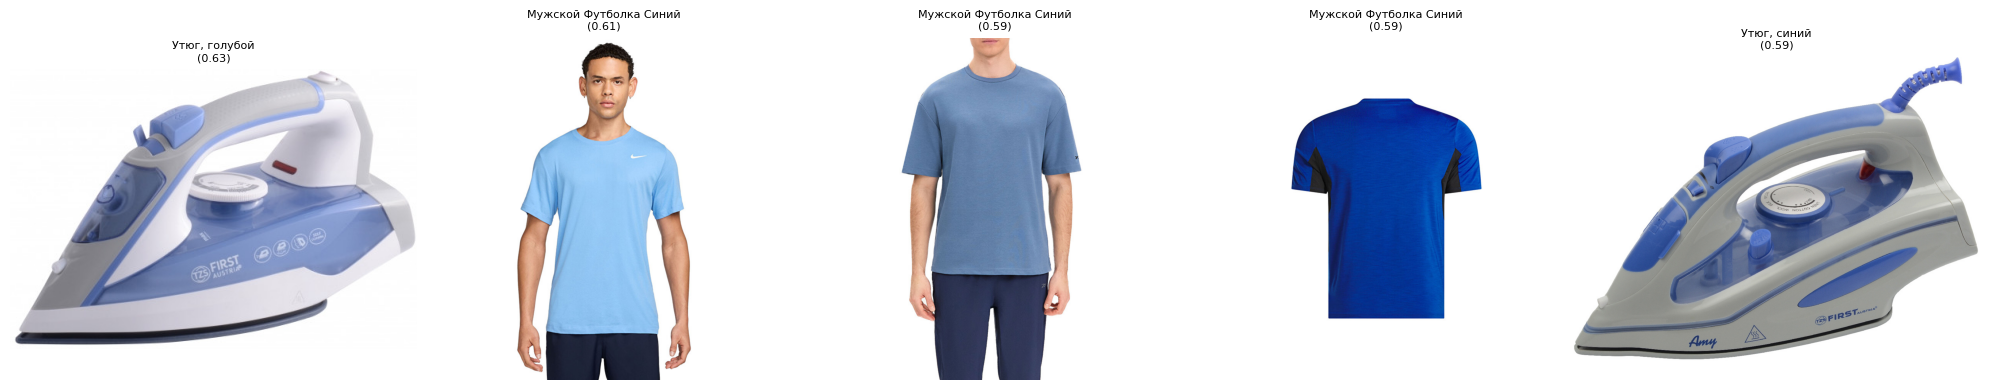

In [90]:
show_results(top_results)

#### RUSSIAN

In [91]:
query = "монитор" # monitor
query_emb = encode_text_query(query, flip_dual_encoderv2)

# Compute cosine similarities
sims = cosine_similarity([query_emb], image_embs_array).flatten()

🔁 Final image_embedding: <class 'NoneType'> None
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


In [92]:
top_k_indices = sims.argsort()[-5:][::-1]
top_results = all_products_combined.iloc[top_k_indices][['title', 'windows_image_path']]
top_results['similarity'] = sims[top_k_indices]

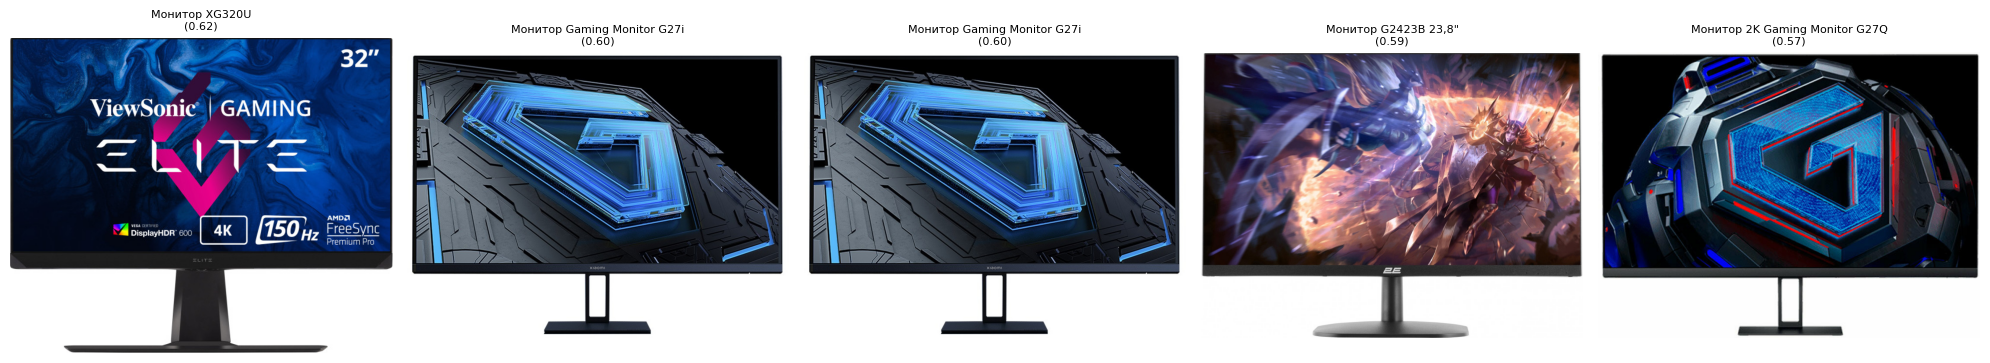

In [93]:
show_results(top_results)

#### KOREAN

In [95]:
query = "믹서" #mixer
query_emb = encode_text_query(query, flip_dual_encoderv2)

# Compute cosine similarities
sims = cosine_similarity([query_emb], image_embs_array).flatten()

🔁 Final image_embedding: <class 'NoneType'> None
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


In [96]:
top_k_indices = sims.argsort()[-5:][::-1]
top_results = all_products_combined.iloc[top_k_indices][['title', 'windows_image_path']]
top_results['similarity'] = sims[top_k_indices]

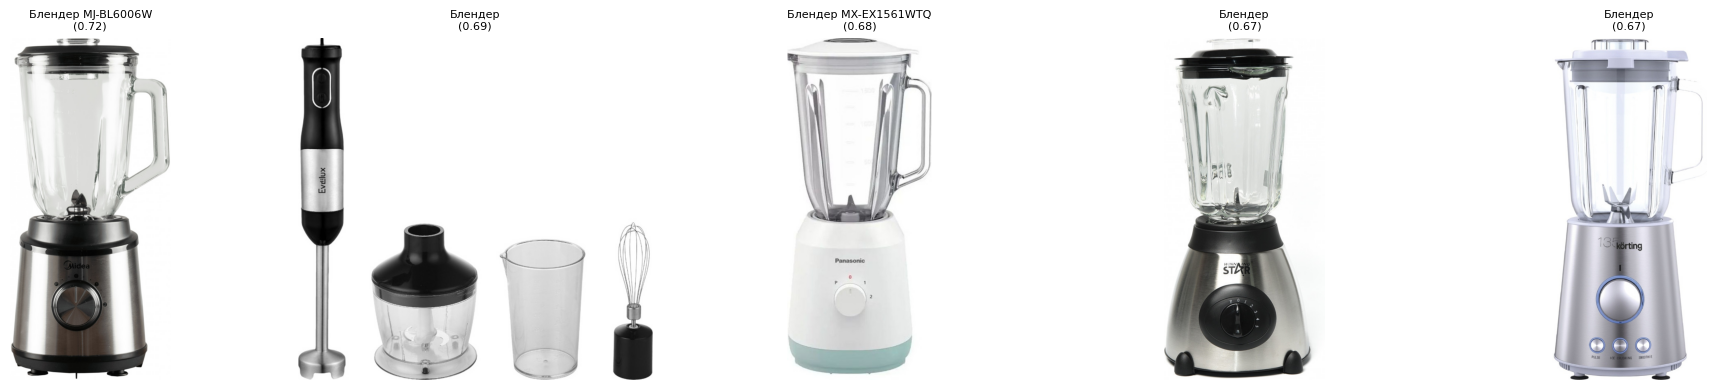

In [97]:
show_results(top_results)

#### GERMAN

In [98]:
query = "Kopfhörer" #earphones
query_emb = encode_text_query(query, flip_dual_encoderv2)

# Compute cosine similarities
sims = cosine_similarity([query_emb], image_embs_array).flatten()

🔁 Final image_embedding: <class 'NoneType'> None
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


In [99]:
top_k_indices = sims.argsort()[-5:][::-1]
top_results = all_products_combined.iloc[top_k_indices][['title', 'windows_image_path']]
top_results['similarity'] = sims[top_k_indices]

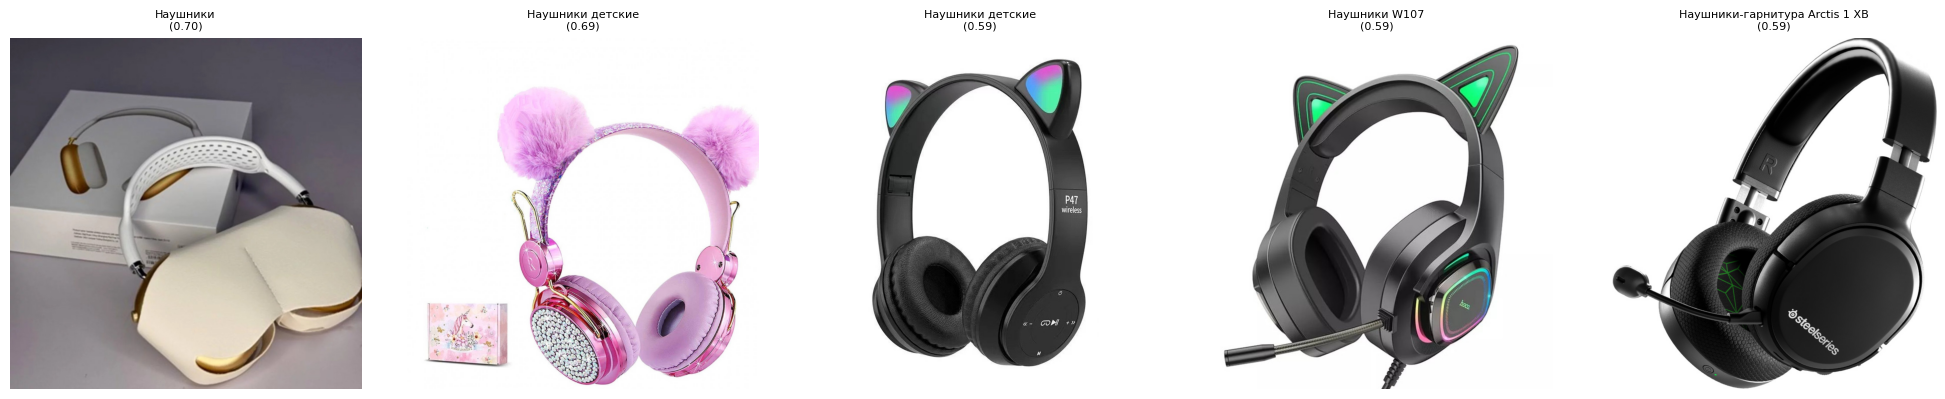

In [100]:
show_results(top_results)

#### ARABIC

In [101]:
query = "حمالة الصدر" #bra
query_emb = encode_text_query(query, flip_dual_encoderv2)

# Compute cosine similarities
sims = cosine_similarity([query_emb], image_embs_array).flatten()

🔁 Final image_embedding: <class 'NoneType'> None
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


In [102]:
top_k_indices = sims.argsort()[-5:][::-1]
top_results = all_products_combined.iloc[top_k_indices][['title', 'windows_image_path']]
top_results['similarity'] = sims[top_k_indices]

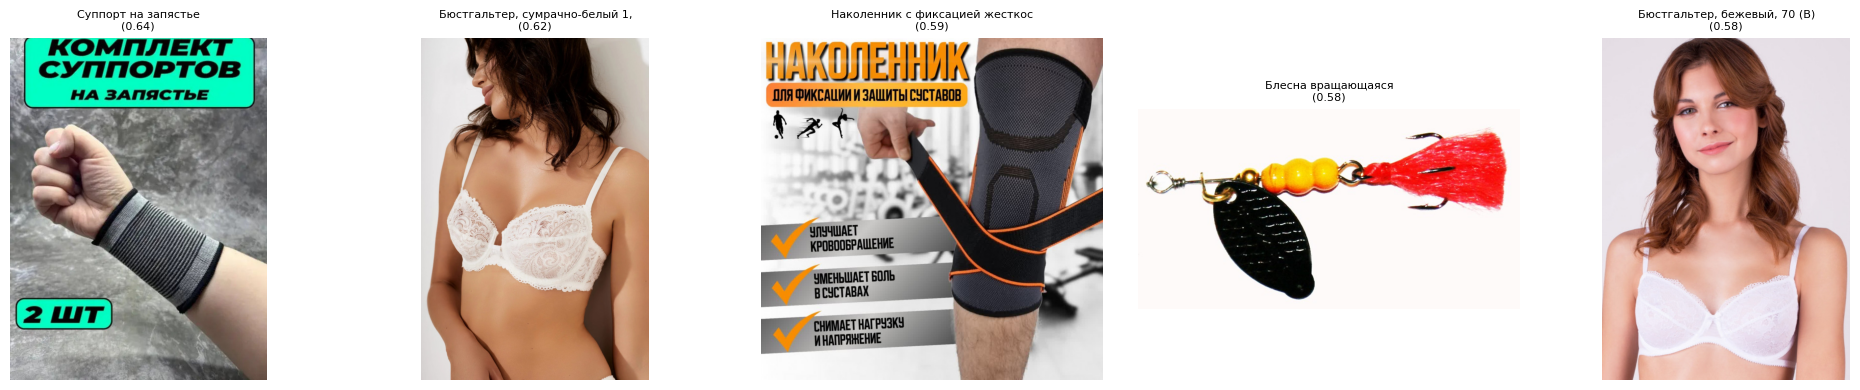

In [103]:
show_results(top_results)

### EMBEDDING FEATURE SPACE

In [74]:
test_images_paths = [r"C:\Users\User\Downloads\apple.jpg",
                     r"C:\Users\User\Downloads\woman suit.jpg",
                     r"C:\Users\User\Downloads\white sneakers.jfif",
                     r"C:\Users\User\Downloads\knife.jfif",
                     r"C:\Users\User\Downloads\wheel.jfif",
                     r"C:\Users\User\Downloads\purple jacket.jfif",
                     r"C:\Users\User\Downloads\Fridge_Thumbnail__0016_DFF180E2SSDB.jpg",
                     r"C:\Users\User\Downloads\laptop.jfif",
                     r"C:\Users\User\Downloads\beige shoes.jpg",
                     r"C:\Users\User\Downloads\boxing gloves.jfif",
                     r"C:\Users\User\Downloads\press grill.jfif"]

test_images_labels = ['apple',
                      'woman suit',
                      'белые кроссовки', # white shoes
                      'Messer', # knife
                      'roue', # wheel
                      'purple jacket',
                      'fridge',
                      'ноутбук', # laptop
                      'scarpe da ginnastica beige', # beige sneakers
                      'перчатки боксёрские', # boxing gloves
                      'press grill']


📸 Got image tensor with shape: torch.Size([1, 3, 224, 224])
✅ ResNet output: torch.Size([1, 2048])
✅ Image embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([1, 256])
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


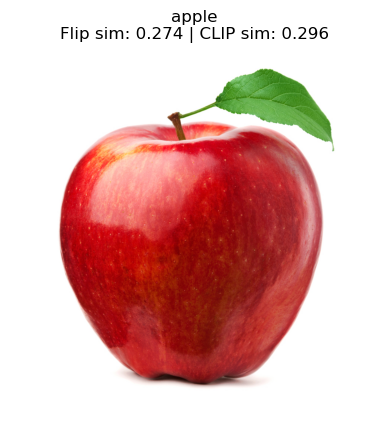

📸 Got image tensor with shape: torch.Size([1, 3, 224, 224])
✅ ResNet output: torch.Size([1, 2048])
✅ Image embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([1, 256])
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


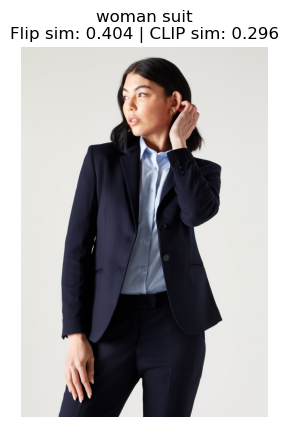

📸 Got image tensor with shape: torch.Size([1, 3, 224, 224])
✅ ResNet output: torch.Size([1, 2048])
✅ Image embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([1, 256])
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


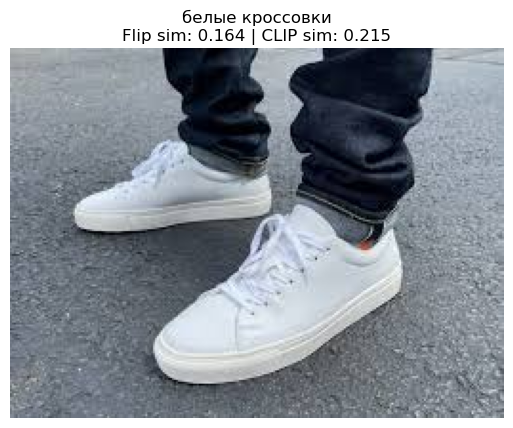

📸 Got image tensor with shape: torch.Size([1, 3, 224, 224])
✅ ResNet output: torch.Size([1, 2048])
✅ Image embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([1, 256])
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


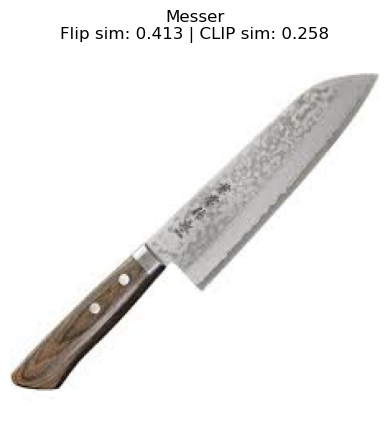

📸 Got image tensor with shape: torch.Size([1, 3, 224, 224])
✅ ResNet output: torch.Size([1, 2048])
✅ Image embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([1, 256])
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


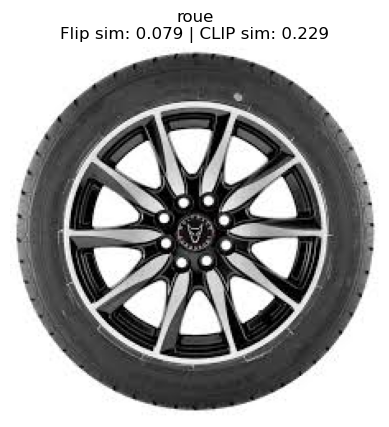

📸 Got image tensor with shape: torch.Size([1, 3, 224, 224])
✅ ResNet output: torch.Size([1, 2048])
✅ Image embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([1, 256])
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


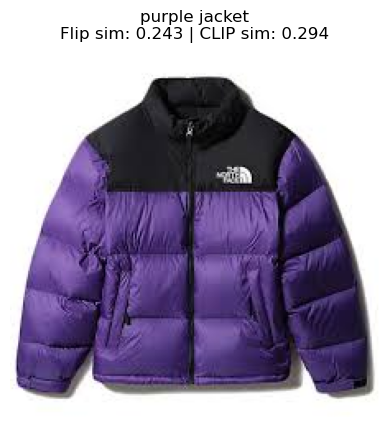

📸 Got image tensor with shape: torch.Size([1, 3, 224, 224])
✅ ResNet output: torch.Size([1, 2048])
✅ Image embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([1, 256])
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


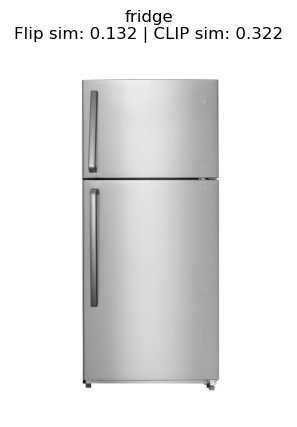

📸 Got image tensor with shape: torch.Size([1, 3, 224, 224])
✅ ResNet output: torch.Size([1, 2048])
✅ Image embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([1, 256])
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


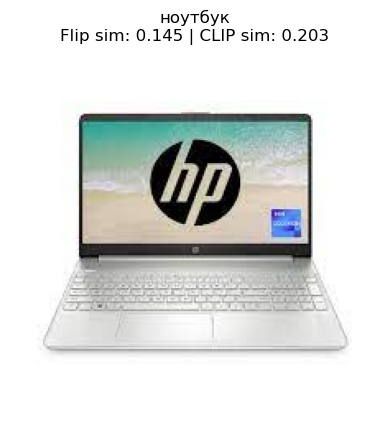

📸 Got image tensor with shape: torch.Size([1, 3, 224, 224])
✅ ResNet output: torch.Size([1, 2048])
✅ Image embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([1, 256])
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


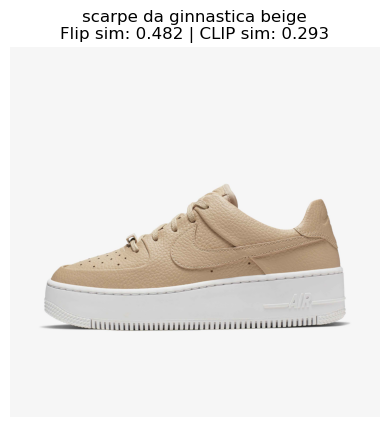

📸 Got image tensor with shape: torch.Size([1, 3, 224, 224])
✅ ResNet output: torch.Size([1, 2048])
✅ Image embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([1, 256])
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


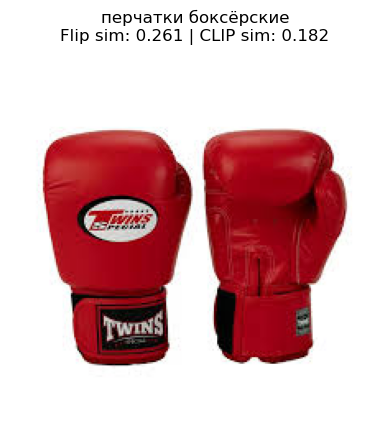

📸 Got image tensor with shape: torch.Size([1, 3, 224, 224])
✅ ResNet output: torch.Size([1, 2048])
✅ Image embedding: torch.Size([1, 256])
🔁 Final image_embedding: <class 'torch.Tensor'> torch.Size([1, 256])
🔁 Final text_embedding: <class 'torch.Tensor'> torch.Size([1, 256])


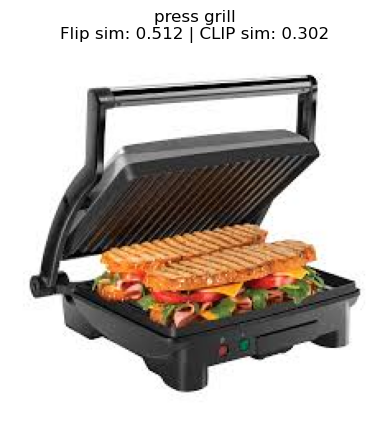

In [75]:
import torchvision.transforms as T
import torch.nn.functional as F


device = 'cpu'
flup_dual_encoderv2.to(device)

flip_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Loop through each image–text pair
for img_path, label in zip(test_images_paths, test_images_labels):
    # Load and show image
    image = Image.open(img_path).convert("RGB")

    # ----- CLIP -----
    clip_inputs = clip_processor(images=image, text=[label], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        clip_outputs = clip_model(**clip_inputs)
        clip_image_embed = F.normalize(clip_outputs.image_embeds[0], dim=-1)
        clip_text_embed = F.normalize(clip_outputs.text_embeds[0], dim=-1)
        clip_sim = F.cosine_similarity(clip_image_embed, clip_text_embed, dim=0).item()

    # ----- Flip -----
    flip_img_tensor = flip_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        flip_img_embed, flip_txt_embed = flup_dual_encoderv2(images=flip_img_tensor, texts=[label])
        flip_sim = F.cosine_similarity(flip_img_embed[0], flip_txt_embed[0], dim=0).item()

    # ----- Display -----
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{label}\nFlip sim: {flip_sim:.3f} | CLIP sim: {clip_sim:.3f}")
    plt.show()
